# Introducción al flujo de trabajo de Machine Learning

En este notebook construiremos nuestro primer modelo de aprendizaje supervisado.

El objetivo es comprender el flujo general de un proyecto de Machine Learning:

1. Generar o recolectar datos.
2. Explorar los datos.
3. Separar los datos en entrenamiento y prueba.
4. Entrenar un modelo.
5. Generar predicciones.
6. Evaluar el desempeño.
7. Interpretar los resultados.

Utilizaremos un problema sintético de regresión generado con `scikit-learn`.

In [1]:
# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt

# Generación de datos sintéticos
from sklearn.datasets import make_regression

# Separación de datos
from sklearn.model_selection import train_test_split

# Modelo
from sklearn.linear_model import LinearRegression

# Métricas
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
)

# Configuración para reproducibilidad
RANDOM_STATE = 42

# Mostrar números con tres decimales
pd.options.display.float_format = "{:,.3f}".format

## 1. Generación de los datos

Generaremos un problema de regresión con una variable explicativa.

La relación subyacente será aproximadamente:

\[
y = \beta_0 + \beta_1 x + \varepsilon,
\]

donde:

- \(x\) es la variable explicativa;
- \(y\) es la variable objetivo;
- \(\beta_0\) es el intercepto;
- \(\beta_1\) es la pendiente;
- \(\varepsilon\) representa el ruido aleatorio.

Al tratarse de datos sintéticos, conocemos el proceso que generó las observaciones.

In [6]:
# Generamos un problema de regresión con una sola variable explicativa
X, y, true_coefficients = make_regression(
    n_samples=200,
    n_features=1,
    n_informative=1,
    noise=20,
    bias=30,
    coef=True,
    random_state=RANDOM_STATE,
)

print(f"Dimensión de X: {X.shape}")
print(f"Dimensión de y: {y.shape}")
print(f"Coeficiente verdadero: {true_coefficients:.3f}")

Dimensión de X: (200, 1)
Dimensión de y: (200,)
Coeficiente verdadero: 87.737


El parámetro `noise` controla cuánto se alejan las observaciones de la relación lineal perfecta.

Cuando el ruido es bajo, los puntos se encuentran cerca de una recta. Cuando el ruido aumenta, la relación se vuelve más difícil de identificar.

In [7]:
# Convertimos los arreglos en un DataFrame para facilitar su exploración
data = pd.DataFrame(
    {
        "x": X[:, 0],
        "y": y,
    }
)

data.head()

,x,y
0,1.852,167.096
1,0.474,89.003
2,-1.231,-46.592
3,0.626,90.804
4,-0.072,21.114


In [8]:
data.describe()

,x,y
count,200.000,200.000
mean,-0.041,29.310
std,0.931,83.477
min,-2.620,-186.906
25%,-0.705,-28.434
50%,-0.004,31.406
75%,0.501,79.069
max,2.720,263.016


## 2. Exploración visual

Antes de construir un modelo conviene observar la relación entre las variables.

En este caso utilizamos una gráfica de dispersión porque contamos con una sola variable explicativa.

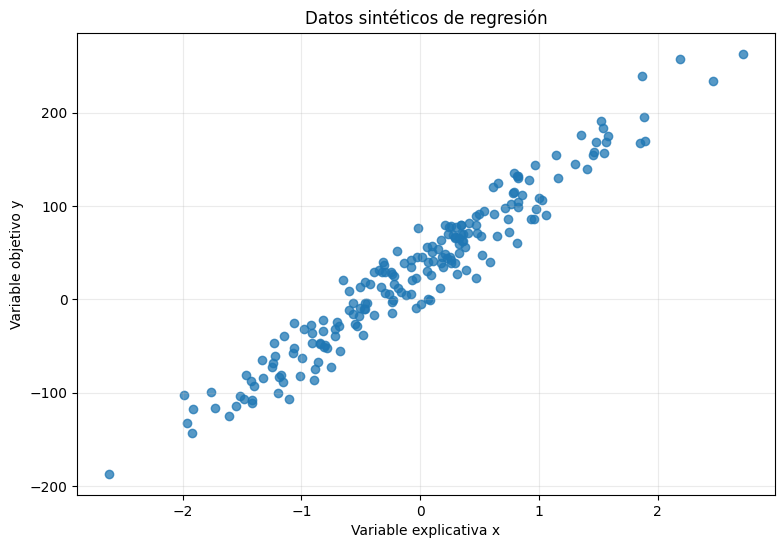

In [9]:
plt.figure(figsize=(9, 6))

plt.scatter(
    data["x"],
    data["y"],
    alpha=0.75,
)

plt.xlabel("Variable explicativa x")
plt.ylabel("Variable objetivo y")
plt.title("Datos sintéticos de regresión")
plt.grid(alpha=0.25)

plt.show()

La nube de puntos sugiere una relación positiva entre \(x\) y \(y\).

El objetivo del modelo será estimar una función que permita predecir \(y\) a partir de nuevos valores de \(x\).

## 3. Separación de los datos

Dividiremos los datos en dos subconjuntos:

- **Entrenamiento:** se utiliza para estimar los parámetros del modelo.
- **Prueba:** se utiliza para evaluar el modelo sobre observaciones que no fueron utilizadas durante el entrenamiento.

La evaluación debe realizarse sobre datos no observados por el modelo.

Observaciones de entrenamiento: 150
Observaciones de prueba: 50


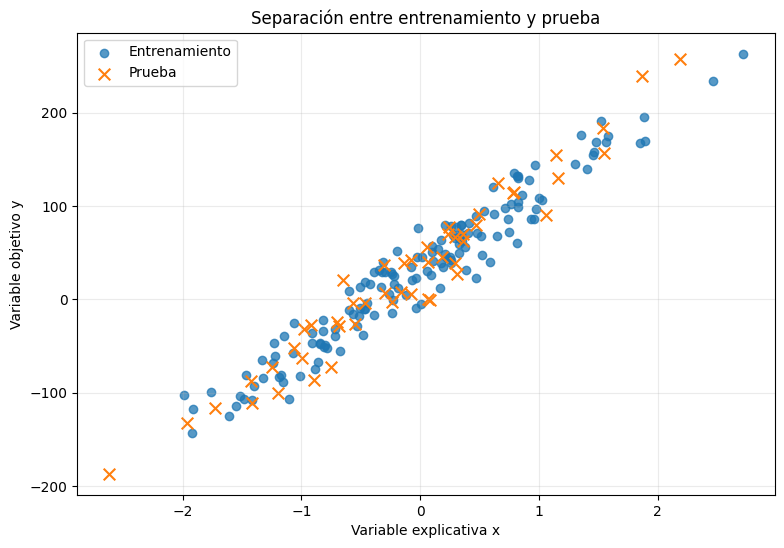

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_STATE,
)

print(f"Observaciones de entrenamiento: {X_train.shape[0]}")
print(f"Observaciones de prueba: {X_test.shape[0]}")

plt.figure(figsize=(9, 6))

plt.scatter(
    X_train[:, 0],
    y_train,
    label="Entrenamiento",
    alpha=0.75,
)

plt.scatter(
    X_test[:, 0],
    y_test,
    label="Prueba",
    marker="x",
    s=70,
)

plt.xlabel("Variable explicativa x")
plt.ylabel("Variable objetivo y")
plt.title("Separación entre entrenamiento y prueba")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## 4. Construcción del modelo

Utilizaremos una regresión lineal.

El modelo estima una función de la forma:

\[
\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x.
\]

El método `fit` utiliza los datos de entrenamiento para estimar el intercepto y la pendiente.

In [14]:
# Creamos el modelo
model = LinearRegression()

# Entrenamos el modelo
model.fit(X_train, y_train)

print(f"Intercepto estimado: {model.intercept_:.3f}")
print(f"Pendiente estimada: {model.coef_[0]:.3f}")

Intercepto estimado: 32.310
Pendiente estimada: 85.268


Como los datos fueron generados sintéticamente, podemos comparar la pendiente estimada con el coeficiente verdadero utilizado para crear las observaciones.

In [17]:
coefficient_comparison = pd.DataFrame(
    {
        "Parámetro": ["Pendiente"],
        "Valor verdadero": [true_coefficients],
        "Valor estimado": [model.coef_[0]],
    }
)

coefficient_comparison["Diferencia"] = (
    coefficient_comparison["Valor estimado"]
    - coefficient_comparison["Valor verdadero"]
)

coefficient_comparison

,Parámetro,Valor verdadero,Valor estimado,Diferencia
0,Pendiente,87.73730719279554,85.268,-2.470


## 5. Generación de predicciones

Una vez estimado el modelo, utilizamos el método `predict` para obtener predicciones sobre el conjunto de prueba.coefficient_comparison


In [18]:
y_pred = model.predict(X_test)

predictions = pd.DataFrame(
    {
        "x": X_test[:, 0],
        "y_real": y_test,
        "y_predicha": y_pred,
    }
)

predictions["residuo"] = (
    predictions["y_real"]
    - predictions["y_predicha"]
)

predictions.head(10)

,x,y_real,y_predicha,residuo
0,0.782,114.012,98.975,15.038
1,0.297,39.174,57.634,-18.460
2,-1.425,-87.857,-89.175,1.317
3,0.069,40.092,38.157,1.935
4,-0.919,-27.581,-46.087,18.506
5,0.791,114.817,99.760,15.057
6,-0.301,36.808,6.636,30.172
7,-0.292,6.979,7.438,-0.460
8,-1.960,-133.095,-134.786,1.692
9,-1.246,-73.049,-73.911,0.862


El residuo de una observación es la diferencia entre el valor observado y la predicción:

\[
e_i = y_i - \hat{y}_i.
\]

Un residuo positivo significa que el modelo subestimó el valor real. Un residuo negativo significa que el modelo lo sobreestimó.

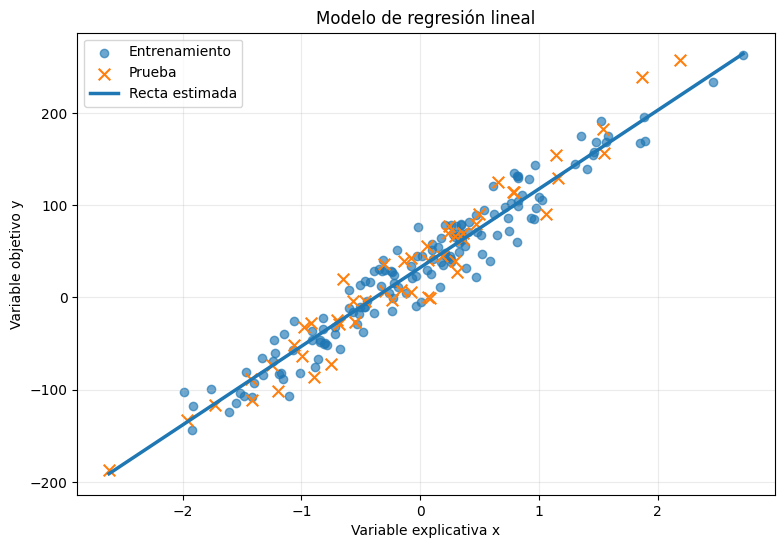

In [19]:
# Creamos una secuencia ordenada de valores para dibujar la recta
x_line = np.linspace(
    X.min(),
    X.max(),
    200,
).reshape(-1, 1)

# Predicciones sobre la secuencia
y_line = model.predict(x_line)

plt.figure(figsize=(9, 6))

plt.scatter(
    X_train[:, 0],
    y_train,
    label="Entrenamiento",
    alpha=0.65,
)

plt.scatter(
    X_test[:, 0],
    y_test,
    label="Prueba",
    marker="x",
    s=70,
)

plt.plot(
    x_line[:, 0],
    y_line,
    linewidth=2.5,
    label="Recta estimada",
)

plt.xlabel("Variable explicativa x")
plt.ylabel("Variable objetivo y")
plt.title("Modelo de regresión lineal")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## 6. Evaluación del modelo

Utilizaremos tres métricas:

### MAE

El error absoluto medio mide la magnitud promedio de los errores:

\[
MAE = \frac{1}{n}\sum_{i=1}^{n}|y_i-\hat{y}_i|.
\]

### RMSE

La raíz del error cuadrático medio penaliza con mayor intensidad los errores grandes:

\[
RMSE =
\sqrt{
\frac{1}{n}
\sum_{i=1}^{n}
(y_i-\hat{y}_i)^2
}.
\]

### \(R^2\)

El coeficiente de determinación mide qué proporción de la variabilidad de \(y\) es explicada por el modelo.

In [20]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame(
    {
        "Métrica": ["MAE", "RMSE", "R²"],
        "Valor": [mae, rmse, r2],
    }
)

metrics

,Métrica,Valor
0,MAE,17.273
1,RMSE,21.959
2,R²,0.943


In [21]:
def evaluate_regression(
    y_true: np.ndarray,
    y_pred: np.ndarray,
) -> pd.DataFrame:
    """
    Calcula métricas básicas para un modelo de regresión.

    Parameters
    ----------
    y_true:
        Valores observados.

    y_pred:
        Valores predichos.

    Returns
    -------
    pd.DataFrame
        Tabla con MAE, RMSE y R².
    """

    results = {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R²": r2_score(y_true, y_pred),
    }

    return pd.DataFrame(
        results.items(),
        columns=["Métrica", "Valor"],
    )


evaluate_regression(y_test, y_pred)

,Métrica,Valor
0,MAE,17.273
1,RMSE,21.959
2,R²,0.943


## 7. Valores observados contra valores predichos

Un modelo perfecto produciría predicciones exactamente iguales a los valores observados.

En una gráfica de valores reales contra valores predichos, esto correspondería a la línea diagonal:

\[
y = \hat{y}.
\]

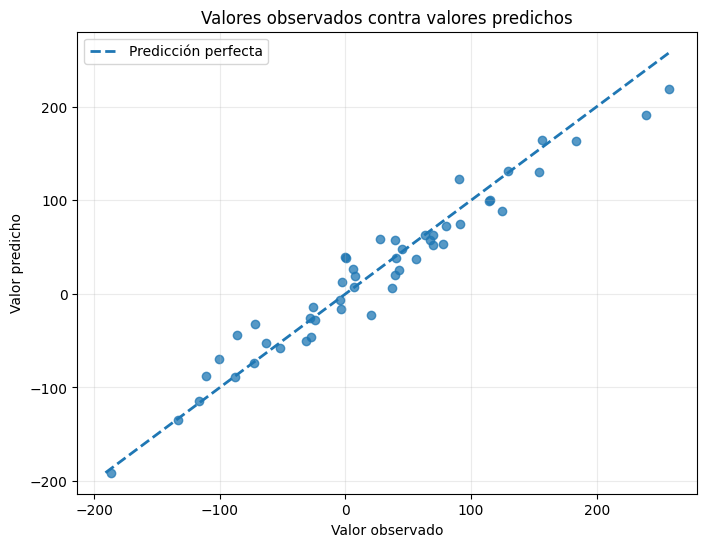

In [22]:
minimum_value = min(y_test.min(), y_pred.min())
maximum_value = max(y_test.max(), y_pred.max())

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.75,
)

plt.plot(
    [minimum_value, maximum_value],
    [minimum_value, maximum_value],
    linestyle="--",
    linewidth=2,
    label="Predicción perfecta",
)

plt.xlabel("Valor observado")
plt.ylabel("Valor predicho")
plt.title("Valores observados contra valores predichos")
plt.legend()
plt.grid(alpha=0.25)

plt.show()

## 8. Análisis de residuos

Los residuos permiten identificar patrones que el modelo no logró capturar.

En una regresión lineal bien especificada, esperamos observar residuos distribuidos alrededor de cero sin una estructura evidente.

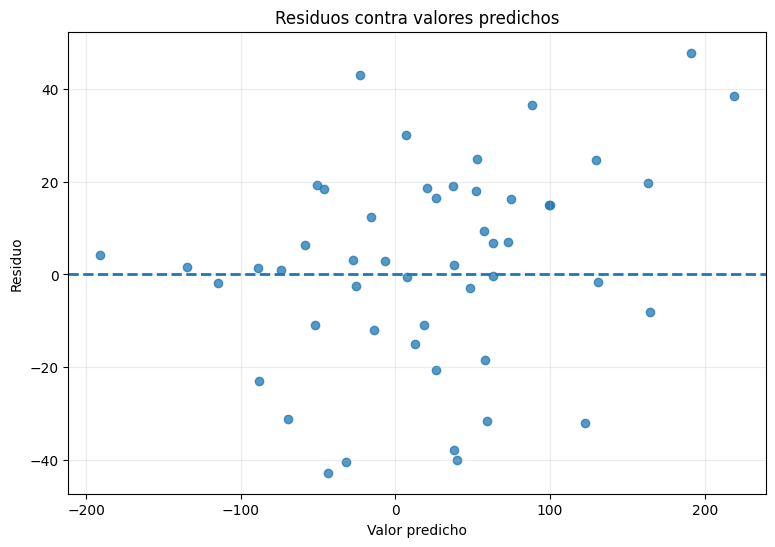

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(9, 6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.75,
)

plt.axhline(
    y=0,
    linestyle="--",
    linewidth=2,
)

plt.xlabel("Valor predicho")
plt.ylabel("Residuo")
plt.title("Residuos contra valores predichos")
plt.grid(alpha=0.25)

plt.show()

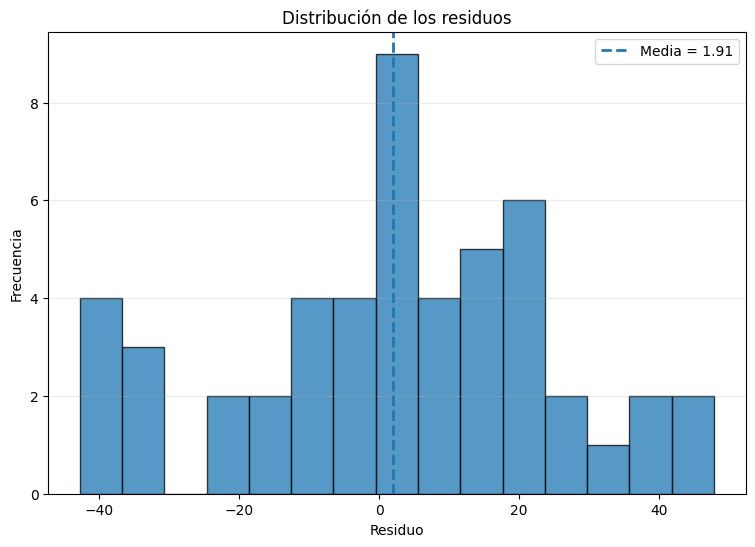

In [24]:
plt.figure(figsize=(9, 6))

plt.hist(
    residuals,
    bins=15,
    edgecolor="black",
    alpha=0.75,
)

plt.axvline(
    residuals.mean(),
    linestyle="--",
    linewidth=2,
    label=f"Media = {residuals.mean():.2f}",
)

plt.xlabel("Residuo")
plt.ylabel("Frecuencia")
plt.title("Distribución de los residuos")
plt.legend()
plt.grid(axis="y", alpha=0.25)

plt.show()

## 9. Predicción de una nueva observación

Podemos utilizar el modelo entrenado para estimar el valor objetivo correspondiente a una nueva observación.

In [25]:
new_x = np.array([[1.5]])

new_prediction = model.predict(new_x)[0]

print(f"Nuevo valor de x: {new_x[0, 0]:.2f}")
print(f"Predicción de y: {new_prediction:.2f}")

Nuevo valor de x: 1.50
Predicción de y: 160.21


## 10. Comparación contra un modelo base

Antes de considerar que un modelo es útil, conviene compararlo con una estrategia sencilla.

En regresión, un modelo base común consiste en predecir siempre la media de la variable objetivo observada en el conjunto de entrenamiento.

In [26]:
# Predicción base: utilizar siempre la media de y en entrenamiento
baseline_prediction = np.repeat(
    y_train.mean(),
    repeats=len(y_test),
)

baseline_metrics = evaluate_regression(
    y_test,
    baseline_prediction,
)

linear_metrics = evaluate_regression(
    y_test,
    y_pred,
)

comparison = pd.concat(
    [
        baseline_metrics.assign(Modelo="Media de entrenamiento"),
        linear_metrics.assign(Modelo="Regresión lineal"),
    ],
    ignore_index=True,
)

comparison = comparison[
    ["Modelo", "Métrica", "Valor"]
]

comparison

,Modelo,Métrica,Valor
0,Media de entrenamiento,MAE,72.144
1,Media de entrenamiento,RMSE,91.973
2,Media de entrenamiento,R²,-0.005
3,Regresión lineal,MAE,17.273
4,Regresión lineal,RMSE,21.959
5,Regresión lineal,R²,0.943


In [27]:
comparison_pivot = comparison.pivot(
    index="Modelo",
    columns="Métrica",
    values="Valor",
)

comparison_pivot

Métrica,MAE,RMSE,R²
Modelo,,,
Media de entrenamiento,72.144,91.973,-0.005
Regresión lineal,17.273,21.959,0.943


## 11. Resumen

En este notebook recorrimos el flujo básico de un problema supervisado:

1. Generamos datos sintéticos.
2. Exploramos la relación entre las variables.
3. Separamos los datos en entrenamiento y prueba.
4. Entrenamos una regresión lineal.
5. Generamos predicciones.
6. Evaluamos el modelo mediante MAE, RMSE y \(R^2\).
7. Analizamos los residuos.
8. Comparamos el modelo contra una estrategia base.

Este mismo flujo aparecerá repetidamente a lo largo del curso, aunque cambiarán:

- el tipo de problema;
- las variables;
- el algoritmo;
- las métricas;
- la estrategia de validación.